使用Adaptive的方法来达到期望变形

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec

# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [92]:
POINTS_NUM:int = 4
num:int = 1
ur_data = pd.read_csv(f'experiment_data{num}.csv')

# 获取并输出列标题
column_titles = ur_data.columns.tolist()
print('Column titles:')
print(column_titles)

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
dot_soft_np = np.loadtxt(f'dots_soft_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')
ja = np.loadtxt(f'ja_list{num}.csv', delimiter=',')
ja_error = np.loadtxt(f'ja_error_list{num}.csv', delimiter=',')

time = ur_data['timestamp'].to_numpy()
time -= time[0]

Column titles:
['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


In [94]:
def plot_loss_and_trajectory(loss_np, df, dot_soft_np):
    rob_pose_x = df['actual_TCP_pose_0'].to_numpy()
    rob_pose_y = df['actual_TCP_pose_1'].to_numpy()

    fig = plt.figure(figsize=(12, 5), dpi=100)
    gs = GridSpec(2, 2, figure=fig)

    # 获取 tab20 颜色映射
    colors = plt.cm.tab20.colors
    # 定义远离红色的颜色（排除红色及其相近颜色）
    filtered_colors = [color for color in colors if not (
        color[0] > 0.8 and color[1] < 0.2 and color[2] < 0.2)]

    step_num = loss_np.shape[0]
    axs_loss = fig.add_subplot(gs[0, :])
    for i in range(loss_np.shape[1]):
        axs_loss.plot(loss_np[:, i], marker='.', linestyle='-', color=filtered_colors[i % len(colors)], label=f'Dot {i+1}')
    axs_loss.plot(np.sum(loss_np, axis=1), marker='.', linestyle='-', color='r', label='Loss Sum')
    axs_loss.set_title('Loss Curve', fontsize=16, fontname='Times New Roman')
    axs_loss.set_xlabel('Iteration', fontsize=14, fontname='Times New Roman')
    axs_loss.set_ylabel('Loss', fontsize=14, fontname='Times New Roman')
    axs_loss.set_xlim([-1, step_num])
    axs_loss.xaxis.set_major_locator(MultipleLocator(20))
    axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
    axs_loss.legend(loc='upper right', fontsize=12)

    sample_rate = 50
    axs_rob_mov = fig.add_subplot(gs[1, 0])
    axs_rob_mov.plot(rob_pose_y[::sample_rate], rob_pose_x[::sample_rate], marker=',', linestyle='-', color='k', label='Trajectory')
    axs_rob_mov.set_title('Robot Tool Movement', fontsize=16, fontname='Times New Roman')
    axs_rob_mov.set_xlabel('X Direction (m)', fontsize=12, fontname='Times New Roman')
    axs_rob_mov.set_ylabel('Y Direction (m)', fontsize=12, fontname='Times New Roman')
    axs_rob_mov.invert_yaxis()
    axs_rob_mov.xaxis.set_label_position('top')
    axs_rob_mov.xaxis.tick_top()
    axs_rob_mov.set_aspect('equal', 'box')

    axs_dot_mov = fig.add_subplot(gs[1, 1])
    for i in range(int(dot_soft_np.shape[1]/3)):
        axs_dot_mov.plot(dot_soft_np[:, 3*i], dot_soft_np[:, 3*i+1], marker=',', linestyle='-', color=filtered_colors[i % len(colors)], label=f'Dot {i+1}')
    axs_dot_mov.set_title('Dot Movement', fontsize=16, fontname='Times New Roman')
    axs_dot_mov.set_xlabel('X Direction (m)', fontsize=12, fontname='Times New Roman')
    axs_dot_mov.set_ylabel('Y Direction (m)', fontsize=12, fontname='Times New Roman')
    axs_dot_mov.invert_yaxis()
    axs_dot_mov.xaxis.set_label_position('top')
    axs_dot_mov.xaxis.tick_top()
    axs_dot_mov.set_aspect('equal', 'box')
    axs_dot_mov.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=12)

    axs = [axs_loss, axs_rob_mov, axs_dot_mov]
    for ax in axs:
        ax.grid(True)

    plt.tight_layout()

In [ ]:
def plot_dot_movement(delta_pos, delta_pos_ada, ja_error):
    # 获取 tab20 颜色映射
    colors = plt.cm.tab20.colors
    # 定义远离红色的颜色（排除红色及其相近颜色）
    filtered_colors = [color for color in colors if not (
        color[0] > 0.8 and color[1] < 0.2 and color[2] < 0.2)]

    fig = plt.figure(figsize=(12, 7), dpi=100)
    gs = GridSpec(2, 1, figure=fig)

    axs_data = fig.add_subplot(gs[0, :])
    for i in range(2*POINTS_NUM):
        axs_data.plot(delta_pos[:, i], marker=',', linestyle='-', color=filtered_colors[i % len(filtered_colors)], label=f'Dim {i+1}')
        axs_data.plot(delta_pos_ada[1:, i], marker=',', linestyle='--', color=filtered_colors[i % len(filtered_colors)], label=f'Dim {i+1} (Adaptive)')
    axs_data.set_title('Dot Movement Delta', fontsize=16, fontname='Times New Roman')
    axs_data.set_xlabel('Iteration', fontsize=14, fontname='Times New Roman')
    axs_data.set_ylabel('Delta (m)', fontsize=14, fontname='Times New Roman')

    axs_error = fig.add_subplot(gs[1, :])
    for i in range(2*POINTS_NUM):
        axs_error.plot(ja_error[1:, i], marker=',', linestyle='-', color=filtered_colors[i % len(filtered_colors)], label=f'Dim {i+1}')
    axs_error.set_title('Dot Movement Error', fontsize=16, fontname='Times New Roman')
    axs_error.set_xlabel('Iteration', fontsize=14, fontname='Times New Roman')
    axs_error.set_ylabel('Error (m)', fontsize=14, fontname='Times New Roman')

    axs = [axs_data, axs_error]
    for ax in axs:
        ax.set_xlim([-1, 200])
        ax.grid(True)
        ax.legend(loc='upper right', fontsize=7)

    plt.tight_layout()

adaptive controller的学习率为1.e0;

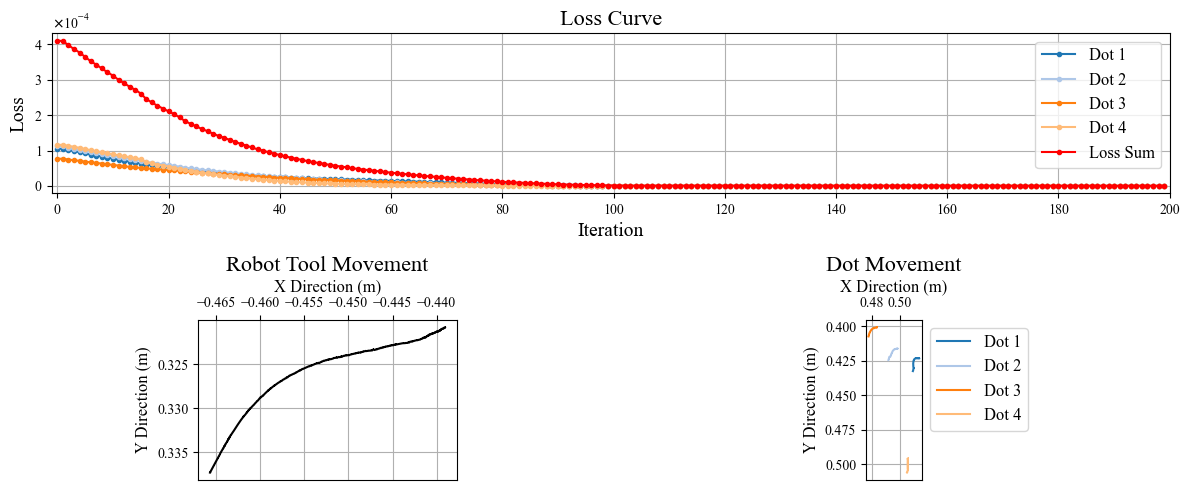

In [ ]:
plot_loss_and_trajectory(loss_np, ur_data, dot_soft_np)

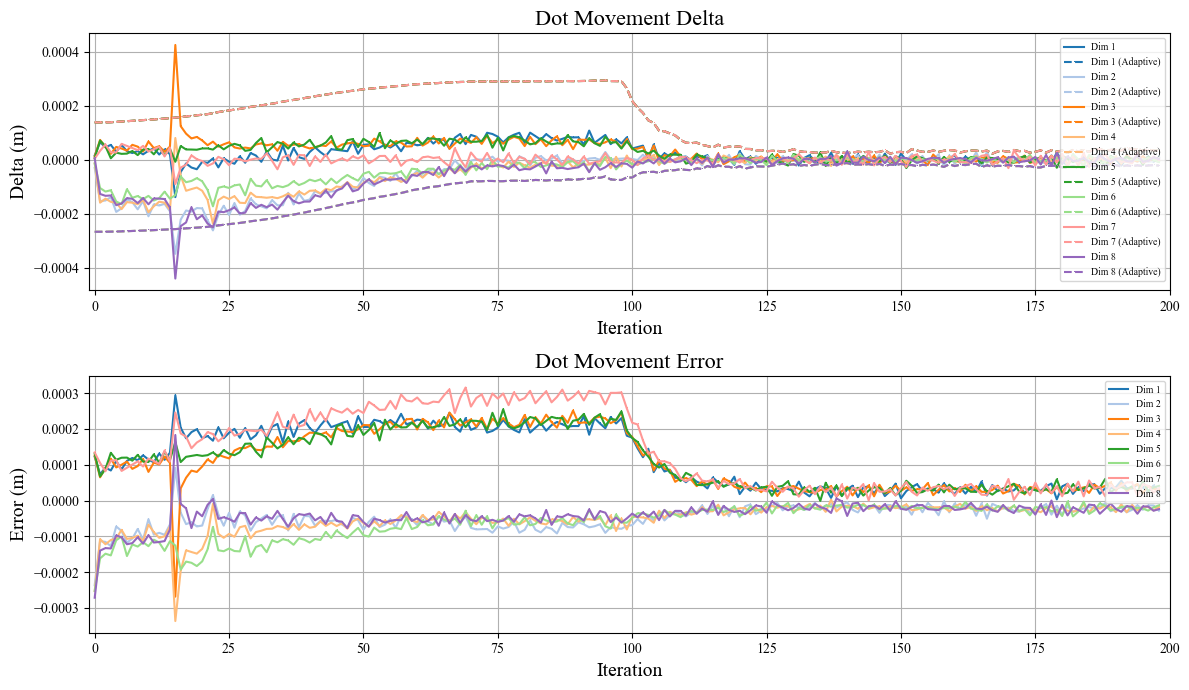

In [97]:
dot_soft_delta = np.diff(dot_soft_np, axis=0)
data_x, data_y = dot_soft_delta[:, 0::3], dot_soft_delta[:, 1::3]
delta_pos = np.zeros((data_x.shape[0], 2*data_x.shape[1]))
delta_pos[:, 0::2] = data_x
delta_pos[:, 1::2] = data_y

delta_pos_ada = np.loadtxt(f'delta_pos_ada_list{num}.csv', delimiter=',')

plot_dot_movement(delta_pos, delta_pos_ada, ja_error)

可以看到Adaptive controller只有一定作用,没有区分接触点的动作对不同Marker点的影响,`Dot Movement Delta`图中所有的虚线退化为两条虚线(表示X和Y方向)

In [99]:
POINTS_NUM:int = 4
num:int = 2
ur_data = pd.read_csv(f'experiment_data{num}.csv')

# 获取并输出列标题
column_titles = ur_data.columns.tolist()
print('Column titles:')
print(column_titles)

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
delta_pos_ada = np.loadtxt(f'delta_pos_ada_list{num}.csv', delimiter=',')
dot_soft_np = np.loadtxt(f'dots_soft_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')
ja = np.loadtxt(f'ja_list{num}.csv', delimiter=',')
ja_error = np.loadtxt(f'ja_error_list{num}.csv', delimiter=',')

time = ur_data['timestamp'].to_numpy()
time -= time[0]

Column titles:
['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


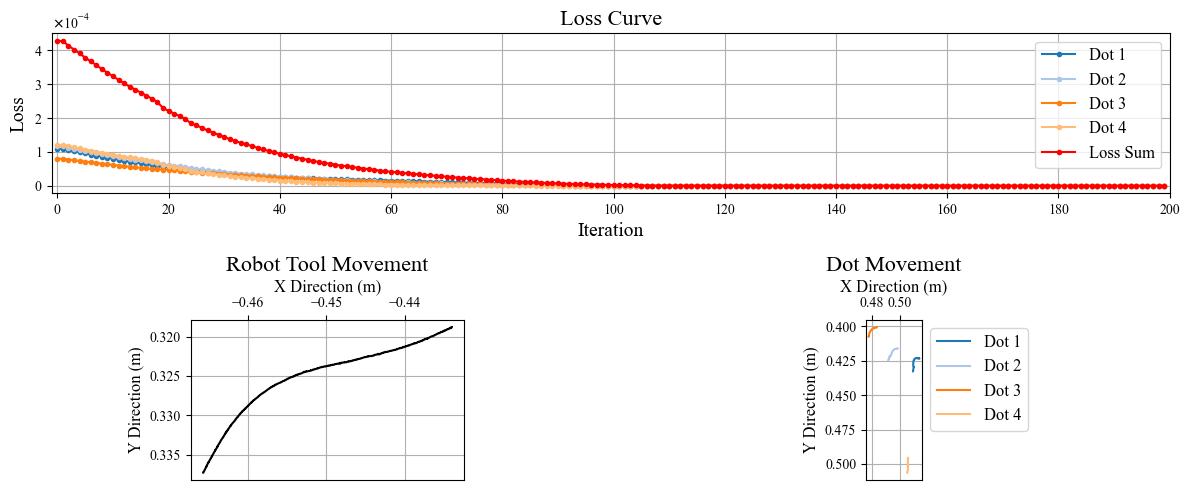

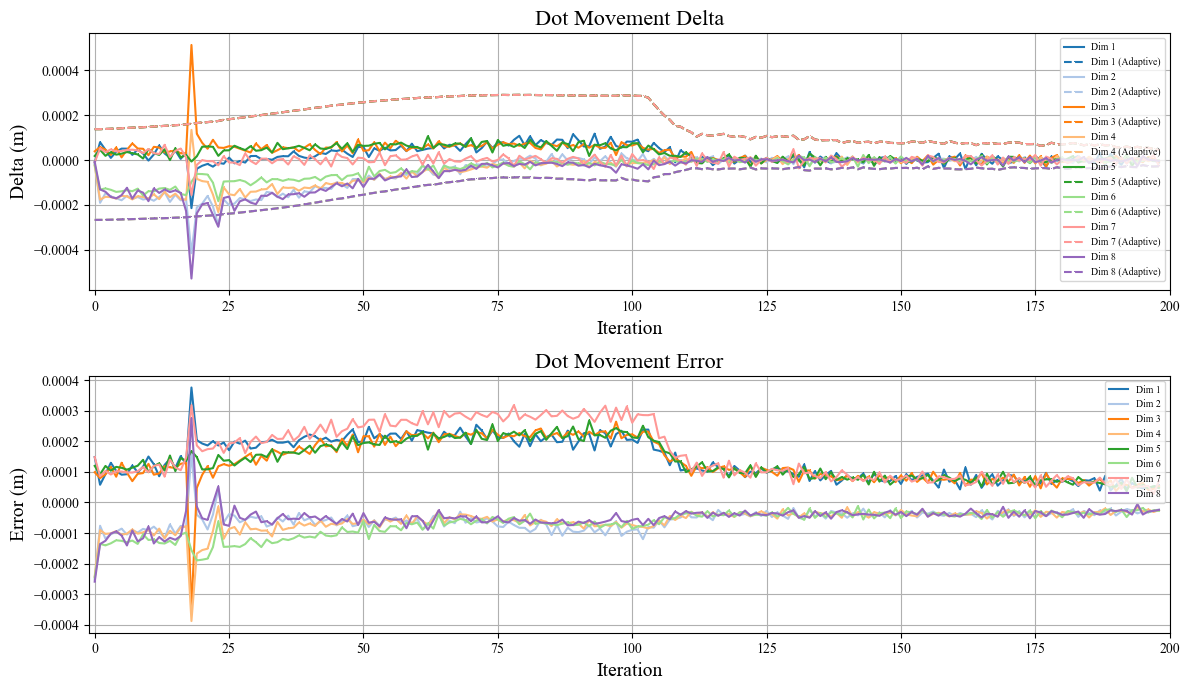

In [100]:
plot_loss_and_trajectory(loss_np, ur_data, dot_soft_np)

dot_soft_delta = np.diff(dot_soft_np, axis=0)
data_x, data_y = dot_soft_delta[:, 0::3], dot_soft_delta[:, 1::3]
delta_pos = np.zeros((data_x.shape[0], 2*data_x.shape[1]))
delta_pos[:, 0::2] = data_x
delta_pos[:, 1::2] = data_y

plot_dot_movement(delta_pos, delta_pos_ada, ja_error)